# Block-Encoded QSVT Laplacian Smoothing

This notebook models a one-dimensional signal on a Dirichlet grid and smooths it with a polynomial of the positive finite-difference Laplacian.

Unlike the earlier dense spectral-polynomial examples, this workflow constructs and verifies an explicit dense unitary block encoding before applying the QSVT polynomial to the normalized signal operator. It also runs the same normalized signal operator through a PennyLane QNode execution path, so the example separates dense reference, finite block verification, and circuit execution.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a one-dimensional denoising/smoothing problem. The input signal is a low-frequency mode contaminated by a higher-curvature component.

**QSVT implementation.** It uses `block_encoded_qsvt_workflow` with the bounded polynomial `P(x) = 1 - x^2` on the normalized positive Laplacian. The workflow builds a dense unitary block encoding, verifies the top-left block and unitarity, applies the QSVT polynomial, and compares the logical QSVT block with an exact spectral reference. A second check uses `execute_qsvt_circuit` to prepare the normalized signal in a PennyLane QNode, queue `qml.qsvt`, and measure the simulator state.

**Classical reference and quantum relevance.** The exact spectral polynomial action validates the finite instance. For larger sparse differential operators, QSVT can apply polynomial filters from block encodings without explicitly diagonalizing the operator, provided scalable state preparation, block encoding, success-probability management, and readout models are supplied separately.

## Variable definitions

- `n_points`: number of interior grid points.
- `length`: physical interval length.
- `grid`, `laplacian`: Dirichlet grid coordinates and positive finite-difference Laplacian.
- `low_mode`, `high_mode`: smooth and high-curvature signal components.
- `signal`: input vector to be filtered.
- `normalized_signal`: unit-norm state prepared in the QNode execution check.
- `coeffs`: polynomial coefficients for `P(x) = 1 - x^2` in ascending degree order.
- `result`: block-encoded QSVT workflow result dataclass.
- `qnode_execution`: finite QNode execution result for the normalized signal operator.
- `report`: JSON-safe report view of `result`.
- `alpha`: block-encoding normalization, so the encoded signal operator is `laplacian / alpha`.
- `scaled_evals`: eigenvalues of the normalized signal operator.
- `filter_values`: values of `P` on `scaled_evals`.
- `reference`, `filtered`: exact spectral and QSVT-filtered output vectors.
- `qnode_real_error`: norm error between the real QNode logical output and the spectral reference for the normalized state.
- `fig`, `ax`, `axes`, and similar names are plotting helpers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt import (
    block_encoded_qsvt_workflow,
    dirichlet_laplacian_1d,
    execute_qsvt_circuit,
)
from qsvt.polynomials import eval_polynomial
from qsvt.reports import report_to_jsonable
from qsvt.spectral import eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

## Block-Encoded Smoothing Setup

The positive Laplacian assigns larger eigenvalues to higher-curvature modes. The polynomial `1 - x^2` preserves low normalized eigenvalues and damps larger ones.

In [2]:
n_points = 8
length = 1.0
grid, laplacian = dirichlet_laplacian_1d(n_points, length=length)

low_mode = np.sin(np.pi * grid)
high_mode = np.sin(6.0 * np.pi * grid)
signal = low_mode + 0.3 * high_mode
coeffs = np.array([1.0, 0.0, -1.0])

result = block_encoded_qsvt_workflow(
    laplacian,
    coeffs,
    state=signal,
)
report = report_to_jsonable(result.as_report())

alpha = report["block_encoding"]["alpha"]
scaled_evals, _ = eigh_hermitian(result.block_encoding.signal_operator)
filter_values = eval_polynomial(coeffs, scaled_evals)
reference = np.real_if_close(result.reference_state)
filtered = np.real_if_close(result.qsvt_state)

print(f"Block-Encoding Alpha: {alpha:.6g}")
print(f"Logical Dimension: {report['block_encoding']['logical_dimension']}")
print(f"Unitary Dimension: {report['block_encoding']['unitary_dimension']}")
print(f"Block Error: {report['verification']['block_error']:.3e}")
print(f"Unitarity Error: {report['verification']['unitarity_error']:.3e}")
print(f"Operator Relative Error: {report['operator_relative_error']:.3e}")
print(f"State Relative Error: {report['state_relative_error']:.3e}")

Block-Encoding Alpha: 392.788
Logical Dimension: 8
Unitary Dimension: 16
Block Error: 0.000e+00
Unitarity Error: 3.819e-15
Operator Relative Error: 1.001e-12
State Relative Error: 1.001e-12


## QNode execution check

The block-encoded workflow above validates the finite logical QSVT block. This cell executes the same normalized signal operator through a PennyLane QNode with the normalized signal as the prepared input state. The real logical output is compared with the dense spectral reference; the imaginary component is tracked separately because PennyLane QSVT conventions can carry phase information outside the real block comparison.

In [3]:
normalized_signal = signal / np.linalg.norm(signal)

qnode_execution = execute_qsvt_circuit(
    result.block_encoding.signal_operator,
    coeffs,
    normalized_signal,
)

qnode_output = qnode_execution.logical_output
qnode_reference = result.reference_operator @ normalized_signal
qnode_real_error = np.linalg.norm(np.real(qnode_output) - qnode_reference)
qnode_max_imag = np.max(np.abs(np.imag(qnode_output)))

print("QNode Execution Kind:", qnode_execution.execution_kind)
print("QNode Gate Types:", qnode_execution.resource_summary["gate_types"])
print(f"QNode Logical Success Probability: {qnode_execution.logical_success_probability:.12f}")
print(f"QNode Real Logical Error: {qnode_real_error:.3e}")
print(f"QNode Max Imaginary Logical Amplitude: {qnode_max_imag:.3e}")

QNode Execution Kind: pennylane-qnode-statevector-qsvt-execution
QNode Gate Types: {'StatePrep': 1, 'QSVT': 1}
QNode Logical Success Probability: 0.959851950246
QNode Real Logical Error: 9.746e-13
QNode Max Imaginary Logical Amplitude: 4.517e-02


## Dirichlet signal geometry

The grid has fixed endpoints outside the interior sample points. The high-curvature component oscillates more rapidly and is more strongly damped by the Laplacian polynomial.

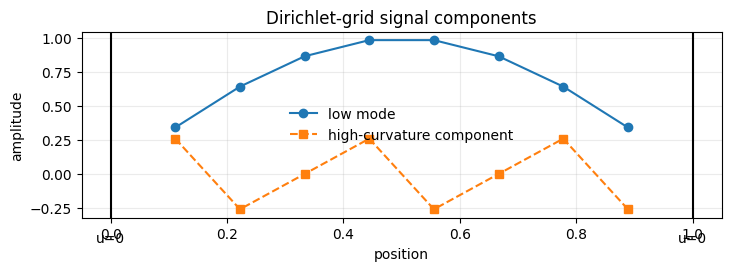

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 2.6), constrained_layout=True)

ax.plot(grid, low_mode, "o-", label="low mode")
ax.plot(grid, 0.3 * high_mode, "s--", label="high-curvature component")
for boundary in [0.0, length]:
    ax.axvline(boundary, color="black", linewidth=1.5)
    ax.text(boundary, -0.42, "u=0", ha="center", va="top")
ax.set_xlabel("position")
ax.set_ylabel("amplitude")
ax.set_title("Dirichlet-grid signal components")
ax.set_xlim(-0.05, length + 0.05)
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)
plt.show()

## QSVT filter diagnostics

The finite block encoding is checked directly. The dense workflow output and the QNode real logical output are both compared with the exact dense spectral polynomial action on the same normalized signal operator.

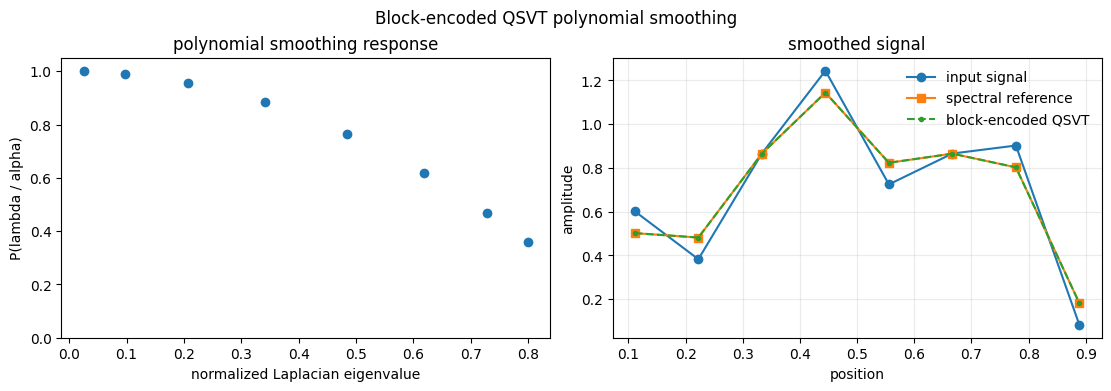

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(scaled_evals, filter_values, "o")
axes[0].set_xlabel("normalized Laplacian eigenvalue")
axes[0].set_ylabel("P(lambda / alpha)")
axes[0].set_title("polynomial smoothing response")
axes[0].set_ylim(0.0, 1.05)

axes[1].plot(grid, signal, "o-", label="input signal")
axes[1].plot(grid, reference, "s-", label="spectral reference")
axes[1].plot(grid, filtered, ".--", label="block-encoded QSVT")
axes[1].set_xlabel("position")
axes[1].set_ylabel("amplitude")
axes[1].set_title("smoothed signal")
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.25)

fig.suptitle("Block-encoded QSVT polynomial smoothing")
plt.show()

The QSVT state, QNode real logical output, and dense spectral reference agree to numerical precision on this finite instance. The block encoding is explicit and verified, while scalable sparse-oracle construction, state preparation, success-probability management, and measurement/readout costs remain separate quantum-algorithm assumptions.

In [6]:
assert report["verification"]["block_encoding_verified"] is True
assert report["verification"]["unitary_verified"] is True
assert report["operator_relative_error"] < 1e-9
assert report["state_relative_error"] < 1e-9
assert qnode_execution.execution_kind == "pennylane-qnode-statevector-qsvt-execution"
assert qnode_execution.resource_summary["gate_types"]["QSVT"] == 1
assert qnode_real_error < 1e-10

print("validation: passed")

validation: passed
